m very high -> y will depend highly on x -> can lead to overfitting

In [27]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

*1 input col and 1 output col*

In [28]:
X,y = make_regression(
    n_samples=100, n_features=1,n_informative=1,n_targets=1,
    noise=20,random_state=13
)

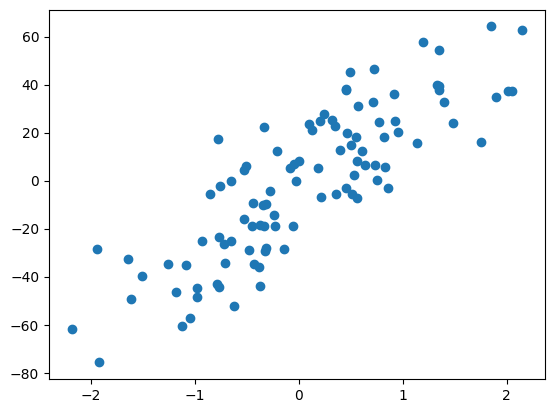

In [36]:
plt.scatter(X,y)

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=2
)

In [37]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [38]:
from sklearn.linear_model import Ridge
rid = Ridge(alpha=10)
rid.fit(X_train,y_train)
print(rid.coef_)
print(rid.intercept_)

[24.84312743]
-2.1047489001173156


In [39]:
rr1 = Ridge(alpha=100)
rr1.fit(X_train,y_train)
print(rr1.coef_)
print(rr1.intercept_)

[12.11579539]
-1.4601506973989027


In [30]:
class MyRidgeReg:
  def __init__(self,alpha=0.1):
    self.m = None
    self.b = None
    self.alpha = alpha

  def fit(self,X_train,y_train):
    y_mean = y_train.mean()
    X_mean = X_train.mean()

    num = 0
    den = 0
    for i in range(X_train.shape[0]):
      num = num + ((y_train[i] - y_mean) * (X_train[i] - X_mean))
      den = den + ((X_train[i] - X_mean) * (X_train[i] - X_mean))

    self.m = num/(den + self.alpha)
    self.b = y_mean - (self.m * X_mean)

  def predict(self,X_test):
    return np.dot(X_test,self.m) + self.b


In [31]:
ridge = MyRidgeReg(alpha=100)
ridge.fit(X_train,y_train)


In [32]:
y_pred = ridge.predict(X_test)


In [34]:
ridge.m

array([12.11579539])

In [35]:
ridge.b

array([-1.4601507])

alpha=0 -> behaves like a linear regression model

m is inversely proportional to alpha

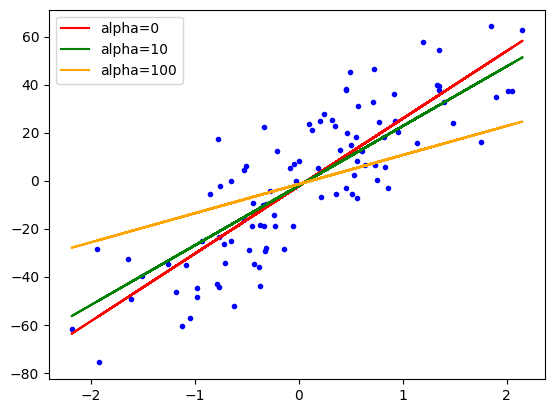

In [40]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rid.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

alpha = 0 -> same as LR

alpha = 10 -> optimum

alpha = 100 -> underfitting

In [41]:
def linear_regression(X,y,alpha=0):
    y_mean = y.mean()
    X_mean = X.mean()

    num = 0
    den = 0
    for i in range(X.shape[0]):
      num = num + ((y[i] - y_mean) * (X[i] - X_mean))
      den = den + ((X[i] - X_mean) * (X[i] - X_mean))

    m = num/(den + alpha)
    b = y_mean - (m * X_mean)

    return m,b